In [1]:
import re
import string
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
def load_and_prepare_data(path):
    data = pd.read_csv(path, encoding="latin-1")

    data = (
        data.rename(columns={"v1": "category", "v2": "message"})
            .drop(columns=[col for col in data.columns if "Unnamed" in col], errors="ignore")
    )

    data["target"] = data["category"].map({"ham": 0, "spam": 1})
    return data

In [3]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess_messages(df):
    df["clean_message"] = df["message"].apply(normalize_text)
    df["msg_length"] = df["message"].str.len()
    return df

In [4]:
def vectorize_text(train_text, test_text):
    vectorizer = CountVectorizer(stop_words=stopwords.words("english"))
    X_train_vec = vectorizer.fit_transform(train_text)
    X_test_vec = vectorizer.transform(test_text)
    return X_train_vec, X_test_vec

In [5]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    acc = accuracy_score(y_test, predictions)

    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, predictions, target_names=["Ham", "Spam"]))

    return acc

In [6]:
data = load_and_prepare_data("spam.csv")
data = preprocess_messages(data)

X = data["clean_message"]
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train_vec, X_test_vec = vectorize_text(X_train, X_test)

In [7]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": SVC(kernel="linear", random_state=42)
}

scores = {}

for model_name, model in models.items():
    scores[model_name] = evaluate_model(
        model,
        X_train_vec,
        X_test_vec,
        y_train,
        y_test,
        model_name
    )


--- Naive Bayes ---
Accuracy: 0.9806
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99      1206
        Spam       0.95      0.90      0.93       187

    accuracy                           0.98      1393
   macro avg       0.97      0.95      0.96      1393
weighted avg       0.98      0.98      0.98      1393


--- Logistic Regression ---
Accuracy: 0.9806
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99      1206
        Spam       1.00      0.86      0.92       187

    accuracy                           0.98      1393
   macro avg       0.99      0.93      0.96      1393
weighted avg       0.98      0.98      0.98      1393


--- Linear SVM ---
Accuracy: 0.9821
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99      1206
        Spam       0.99      0.88      0.93       187

    accuracy                           0.98      1393
   macr

In [8]:
results_df = (
    pd.DataFrame(scores.items(), columns=["Model", "Accuracy"])
      .sort_values(by="Accuracy", ascending=False)
)

print("\n--- Model Performance Summary ---")
print(results_df.to_string(index=False))


--- Model Performance Summary ---
              Model  Accuracy
         Linear SVM  0.982053
        Naive Bayes  0.980617
Logistic Regression  0.980617


C:\Users\abdul\AppData\Local\Temp\ipykernel_12672\3773125752.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="Accuracy", palette="viridis")


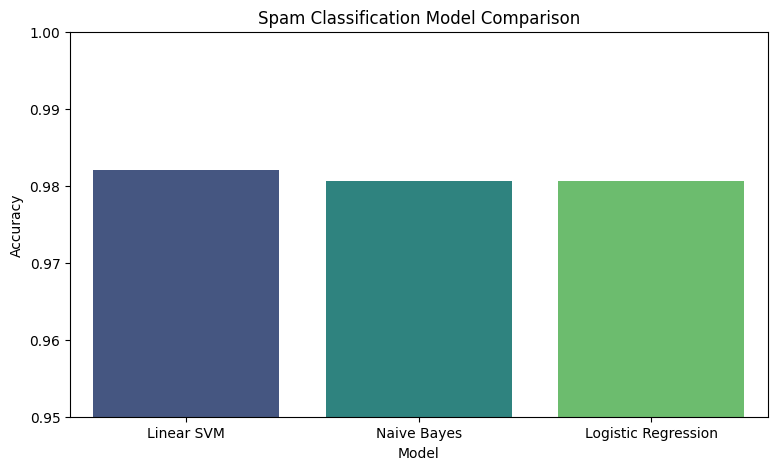

In [9]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy", palette="viridis")
plt.ylim(0.95, 1.0)
plt.title("Spam Classification Model Comparison")
plt.show()